In [1]:
import numpy as np
import cv2 
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms,models
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [3]:
main_path = "/kaggle/input/pets-facial-expression-dataset/Master Folder/"
train_path = main_path+"train/"
val_path = main_path+"valid/"
img_folder = ImageFolder(root=train_path)


# Class Counts and Different Image Sizes

In [4]:
class_counts = {}
image_sizes = {}
for img, img_cls in img_folder:
    if img.size not in image_sizes:
        image_sizes[img.size] = 0
    image_sizes[img.size] += 1
    
    if img_cls not in class_counts:
        class_counts[img_cls] = 0

    class_counts[img_cls] += 1

print(class_counts)
print(image_sizes)

{0: 250, 1: 250, 2: 250, 3: 250}
{(224, 224): 633, (179, 179): 367}


# Augmentations & Transforms

In [5]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

data_transforms = {
    'train':
    transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.01),
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ]),
    'validation':
    transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        normalize
    ]),
}

# Dataset & Dataloader

In [6]:
class PetDataset(Dataset):
    def __init__(self,root_dir,transform=None):
        self.dataset = ImageFolder(root = root_dir,transform=transform)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self,index):
        image , label  = self.dataset[index]
        samples = {'image':image,'label':label}
        return samples
        

In [7]:
train_dataset = PetDataset(train_path,data_transforms['train'])
val_dataset = PetDataset(val_path,data_transforms['validation'])

In [8]:
train_loader = DataLoader(train_dataset,batch_size = 16,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size = 16,shuffle=False)

Feature batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])


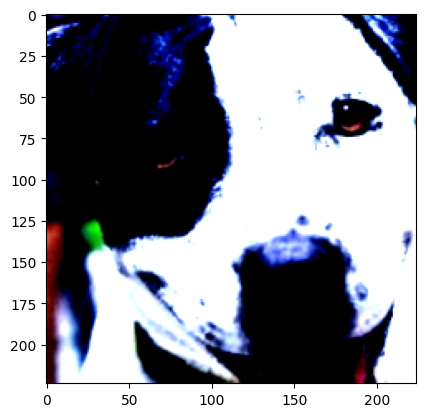

Label: 3


In [9]:
# Display image and label.
batch = next(iter(train_loader))
print(f"Feature batch shape: {batch['image'].size()}")
print(f"Labels batch shape: {batch['label'].size()}")
img = batch['image'][3].squeeze()
label = batch['label'][3]
plt.imshow(img.permute(1, 2, 0))
plt.show()
print(f"Label: {label}")

# Model

In [20]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [23]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs):
        """
        A single block in the VGG network.
        Args:
            in_channels: Number of input channels.
            out_channels: Number of output channels(Kernels).
            num_convs: Number of convolutional layers in the block.
        """
        super(VGGBlock, self).__init__()
        layers = []
        for _ in range(num_convs):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU())
            in_channels = out_channels
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))  # Add max pooling
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)



class VGG(nn.Module):
    def __init__(self, architecture, num_classes=4, input_size=(3, 224, 224)):
        """
        VGG model using VGG blocks, with dynamic classifier size detection.
        Args:
            architecture: List of tuples defining the VGG architecture.
                          Each tuple is (num_convs, out_channels).
            num_classes: Number of output classes for classification.
            input_size: Tuple representing the input size (C, H, W).
        """
        super(VGG, self).__init__()
        self.features = self.create_vgg_layers(architecture)

        # Dynamically calculate the flattened size
        self.flattened_size = self._get_flattened_size(input_size)

        # Define the classifier with the dynamically detected size
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flattened_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _get_flattened_size(self, input_size):
        """
        Calculate the size of the flattened tensor after passing through the feature extractor.
        This allows creating varying input size models and enables constructing variable sized feature extractors.
        Args:
            input_size: Tuple representing the input size (C, H, W).
        Returns:
            int: Flattened size of the tensor.
        """
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_size)  # Batch size 1
            output = self.features(dummy_input)
            return output.numel()  # input size for FC layer

    @staticmethod
    def create_vgg_layers(architecture):
        layers = []
        in_channels = 3  # Starting with RGB images (3 channels)
        for num_convs, out_channels in architecture:
            layers.append(VGGBlock(in_channels, out_channels, num_convs))
            in_channels = out_channels
        return nn.Sequential(*layers)




def vgg16_architecture():
    """
    Returns the architecture for VGG-16.
    Format: [(num_convs, out_channels), ...]
    """
    return [
        (2, 64),  # Block 1: 2 conv layers, 64 filters
        (2, 128),  # Block 2: 2 conv layers, 128 filters
        (3, 256),  # Block 3: 3 conv layers, 256 filters
        (3, 512),  # Block 4: 3 conv layers, 512 filters
        (3, 512),  # Block 5: 3 conv layers, 512 filters
    ]


model = VGG(vgg16_architecture())
model.to(device)

VGG(
  (features): Sequential(
    (0): VGGBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): VGGBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): VGGBlock(
      (block): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): Conv2d(256, 25

# Sample Batch

In [24]:
batch = next(iter(train_loader))
model(batch['image'].to(device)).shape

torch.Size([16, 4])

In [25]:
test_output = model(batch['image'].to(device))
print(test_output.argmax(dim=1))

tensor([0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 2, 0], device='cuda:0')


# Loss and Optimizer

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Training Val Loop

In [27]:
def train_loop(model,loader,epoch):
    train_pred = []
    train_labels = []
    train_loss = 0
    total_samples = 0
    for i,data in enumerate(loader):
        optimizer.zero_grad()
        image = data['image'].to(device)
        label = data['label'].to(device)
        
        outputs = model(image)
        loss = criterion(outputs,label)
        
        loss.backward()
        optimizer.step()
        
        train_loss+= loss.item()
        train_pred.append(torch.argmax(outputs,dim = 1).cpu().detach().numpy())
        train_labels.append(label.cpu().detach().numpy())
        total_samples += data['image'].size(0) 
        
    print("Train Epoch: ",epoch,"| Loss: ",(train_loss/total_samples))
        
    return np.concatenate(train_pred).ravel(), np.concatenate(train_labels).ravel(),(train_loss/total_samples)


def val_loop(model,loader,epoch):
    val_pred = []
    val_labels = []
    val_loss = 0
    total_samples = 0
    with torch.no_grad():
        for i,data in enumerate(loader):
            optimizer.zero_grad()
            image = data['image'].to(device)
            label = data['label'].to(device)
            outputs = model(image)
            loss = criterion(outputs,label)
            val_loss+= loss.item()
            val_pred.append(torch.argmax(outputs,dim = 1).cpu().detach().numpy())
            val_labels.append(label.cpu().detach().numpy())
            total_samples += data['image'].size(0) 
            
        print("Val Epoch: ",epoch,"| Loss: ",(val_loss/total_samples))
        
        return np.concatenate(val_pred).ravel(), np.concatenate(val_labels).ravel(),(val_loss/total_samples)
        
        

In [16]:
# import torch.optim.lr_scheduler as lr_scheduler


# scheduler = lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)  # Reduce LR every 1 epochs by a factor of 0.5

# num_epochs = 10
# train_preds = []
# train_labels = []
# train_loss_list = []

# val_preds = []
# val_labels = []
# val_loss_list = []

# for i in range(num_epochs):
#     current_lr = optimizer.param_groups[0]['lr']
#     print("Epoch: ", i, "| Learning Rate : ", current_lr)
    
#     model.train()
#     train_preds, train_labels, train_loss = train_val(model, train_loader, i + 1, "train")
#     train_loss_list.append(train_loss)
#     print("Train Accuracy: ", accuracy_score(train_labels, train_preds))
    
#     model.eval()
#     val_preds, val_labels, val_loss = train_val(model, val_loader, i + 1, "val")
#     val_loss_list.append(val_loss)
#     print("Val Accuracy: ", accuracy_score(val_labels, val_preds))
    
#     # Update the learning rate at the end of each epoch
#     scheduler.step()


In [ ]:
import os

# Directory to save models
save_dir = "/kaggle/working/saved_models"
os.makedirs(save_dir, exist_ok=True)

num_epochs = 100
patience = 10  # Number of epochs to wait before reducing the learning rate
learning_rate_decay_facor = 0.5
best_val_accuracy = 0
epochs_since_improvement = 0

train_preds = []
train_labels = []
train_loss_list = []

val_preds = []
val_labels = []
val_loss_list = []

for i in range(num_epochs):
    current_lr = optimizer.param_groups[0]['lr']
    print("Epoch: ", i+1, "| Learning Rate : ", current_lr)
    
    # Train phase
    model.train()
    train_preds, train_labels, train_loss = train_loop(model, train_loader, i + 1)
    train_loss_list.append(train_loss)
    print("Train Accuracy: ", accuracy_score(train_labels, train_preds))
    
    # Validation phase
    model.eval()
    val_preds, val_labels, val_loss = val_loop(model, val_loader, i + 1)
    val_loss_list.append(val_loss)
    val_accuracy = accuracy_score(val_labels, val_preds)
    print("Val Accuracy: ", val_accuracy)
    
    # Check for improvement
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_since_improvement = 0
        
        # Save the model
        save_path = os.path.join(save_dir, f"best_model_epoch_{i + 1}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"New best model saved to {save_path}.")
    else:
        epochs_since_improvement += 1

    # Reduce the learning rate if no improvement for 'patience' epochs
    if epochs_since_improvement >= patience:
        current_lr = current_lr * learning_rate_decay_facor
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        print(f"No improvement for {patience} epochs. Reducing learning rate to {current_lr}.")
        epochs_since_improvement = 0


Epoch:  1 | Learning Rate :  1e-05
Train Epoch:  1 | Loss:  0.08739489710330964
Train Accuracy:  0.236
Val Epoch:  1 | Loss:  0.11631044745445251
Val Accuracy:  0.25
New best model saved to /kaggle/working/saved_models/best_model_epoch_1.pth.
Epoch:  2 | Learning Rate :  1e-05
Train Epoch:  2 | Loss:  0.08739750766754151
Train Accuracy:  0.234
Val Epoch:  2 | Loss:  0.11627363827493456
Val Accuracy:  0.25
Epoch:  3 | Learning Rate :  1e-05
Train Epoch:  3 | Loss:  0.08740244495868683
Train Accuracy:  0.234
Val Epoch:  3 | Loss:  0.1162769960032569
Val Accuracy:  0.25
Epoch:  4 | Learning Rate :  1e-05
Train Epoch:  4 | Loss:  0.08739592552185059
Train Accuracy:  0.235
Val Epoch:  4 | Loss:  0.11625669399897258
Val Accuracy:  0.25
Epoch:  5 | Learning Rate :  1e-05
Train Epoch:  5 | Loss:  0.0873794069290161
Train Accuracy:  0.244
Val Epoch:  5 | Loss:  0.11621044741736518
Val Accuracy:  0.25
Epoch:  6 | Learning Rate :  1e-05
Train Epoch:  6 | Loss:  0.08736368262767792
Train Accuracy:

In [ ]:
plt.plot([i+1 for i in range(num_epochs)],train_loss_list,'g',label='Training Loss')
plt.plot([i+1 for i in range(num_epochs)],val_loss_list,'r',label='Val Loss')
plt.title('Training and Testing loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()